# 03 · Feature Engineering & Exploratory Analysis
**Telco Customer Churn Prediction with SQL and Machine Learning**  
*Sections 7-8* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- Binary and one-hot encoding (36 model features)
- Engineered features: CLV, ServiceCount, Price_Segment, Churn_Risk and more
- Univariate distributions and correlation heatmap
- Churn by tenure, price segment, service adoption and senior status

> **How to use these notebooks.** The outputs below come from one complete run in Google Colab. Each part builds on objects created earlier (the SQL database, the prepared DataFrame, trained models), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Data Quality & Preprocessing Study](02_preprocessing_study.ipynb) · [Modelling, Evaluation & Business Insights →](04_modelling_evaluation_insights.ipynb)

---

## 7. ADVANCED FEATURE ENGINEERING

In [51]:
# Binary encoding
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    if col in df.columns:
        df[col] = df[col].map(binary_map)

# One-hot encoding for categorical
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
for col in cat_cols:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)

# Create derived features
df['CLV'] = df['MonthlyCharges'] * df['tenure']
df['Monthly_to_Total'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
service_cols = [col for col in df.columns if col.startswith(('OnlineS', 'OnlineB', 'Device', 'Tech', 'Stream'))]
df['ServiceCount'] = df[service_cols].sum(axis=1)
df['Price_Segment'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 65, 150], labels=[0, 1, 2]).astype(int)
df['Tenure_Squared'] = df['tenure'] ** 2
df['Churn_Risk'] = (df['tenure'] < 6) * 0.4 + (df['MonthlyCharges'] > 65) * 0.3 + (df['ServiceCount'] < 2) * 0.3

print(f'Final Dataset Shape: {df.shape}')
print(f'Total Features: {df.shape[1]}')


Final Dataset Shape: (7043, 38)
Total Features: 38


## 8. EXPLORATORY DATA ANALYSIS

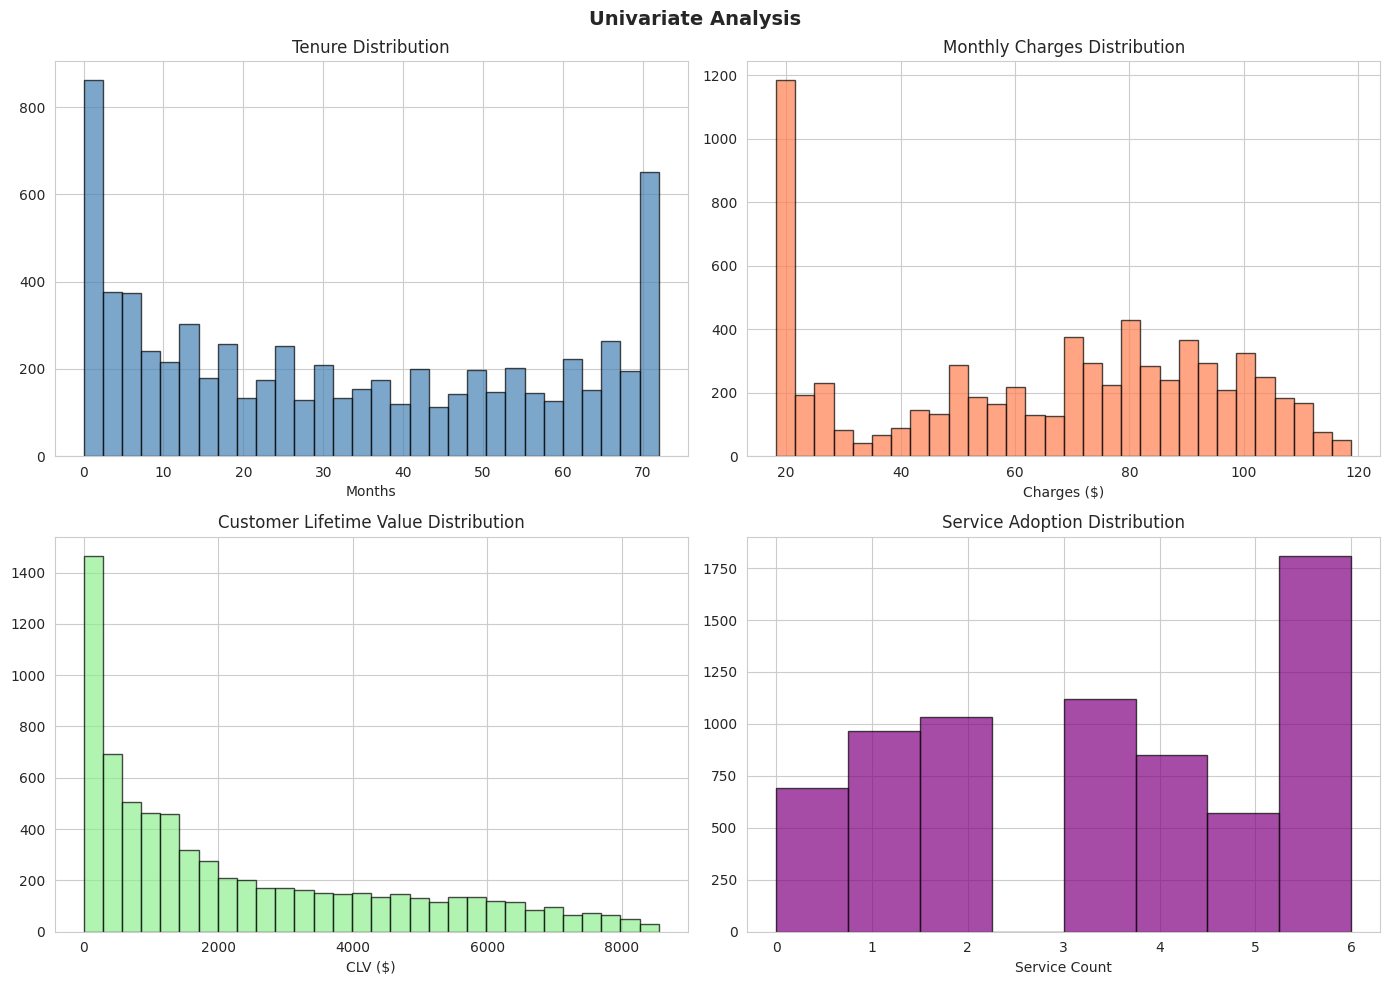

✓ Univariate Analysis Complete


In [52]:
# Type 1: Univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis', fontsize=14, fontweight='bold')

axes[0, 0].hist(df['tenure'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Tenure Distribution')
axes[0, 0].set_xlabel('Months')

axes[0, 1].hist(df['MonthlyCharges'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Monthly Charges Distribution')
axes[0, 1].set_xlabel('Charges ($)')

axes[1, 0].hist(df['CLV'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Customer Lifetime Value Distribution')
axes[1, 0].set_xlabel('CLV ($)')

axes[1, 1].hist(df['ServiceCount'], bins=8, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Service Adoption Distribution')
axes[1, 1].set_xlabel('Service Count')

plt.tight_layout()
plt.show()
print('✓ Univariate Analysis Complete')


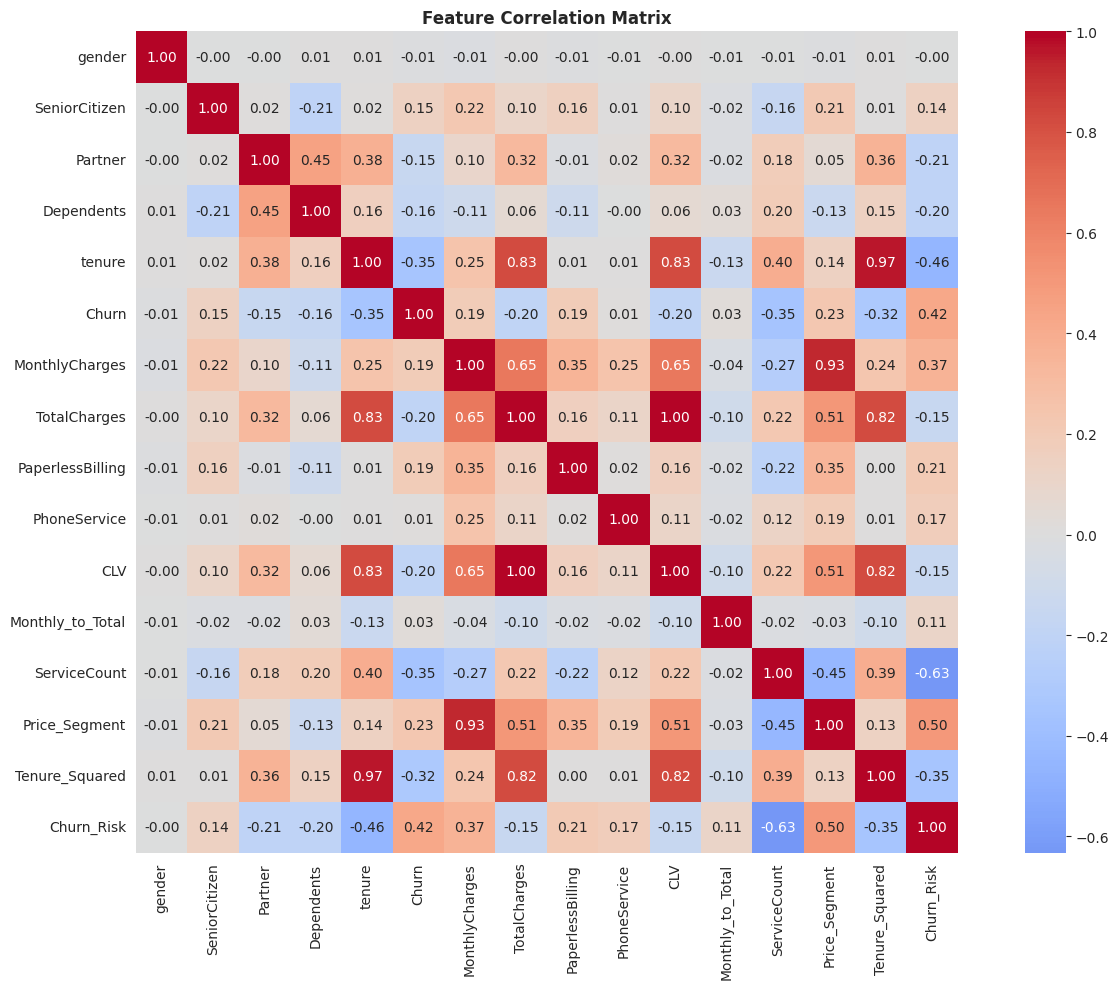


Top Churn Correlations:
Churn               1.000000
Churn_Risk          0.424610
Price_Segment       0.231292
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
Monthly_to_Total    0.026299
PhoneService        0.011942
gender             -0.008612
Partner            -0.150448
Name: Churn, dtype: float64
✓ Bivariate Analysis Complete


In [53]:
# Type 2: Bivariate & Correlation Analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop Churn Correlations:')
if 'Churn' in corr_matrix.columns:
    print(corr_matrix['Churn'].sort_values(ascending=False).head(10))
print('✓ Bivariate Analysis Complete')


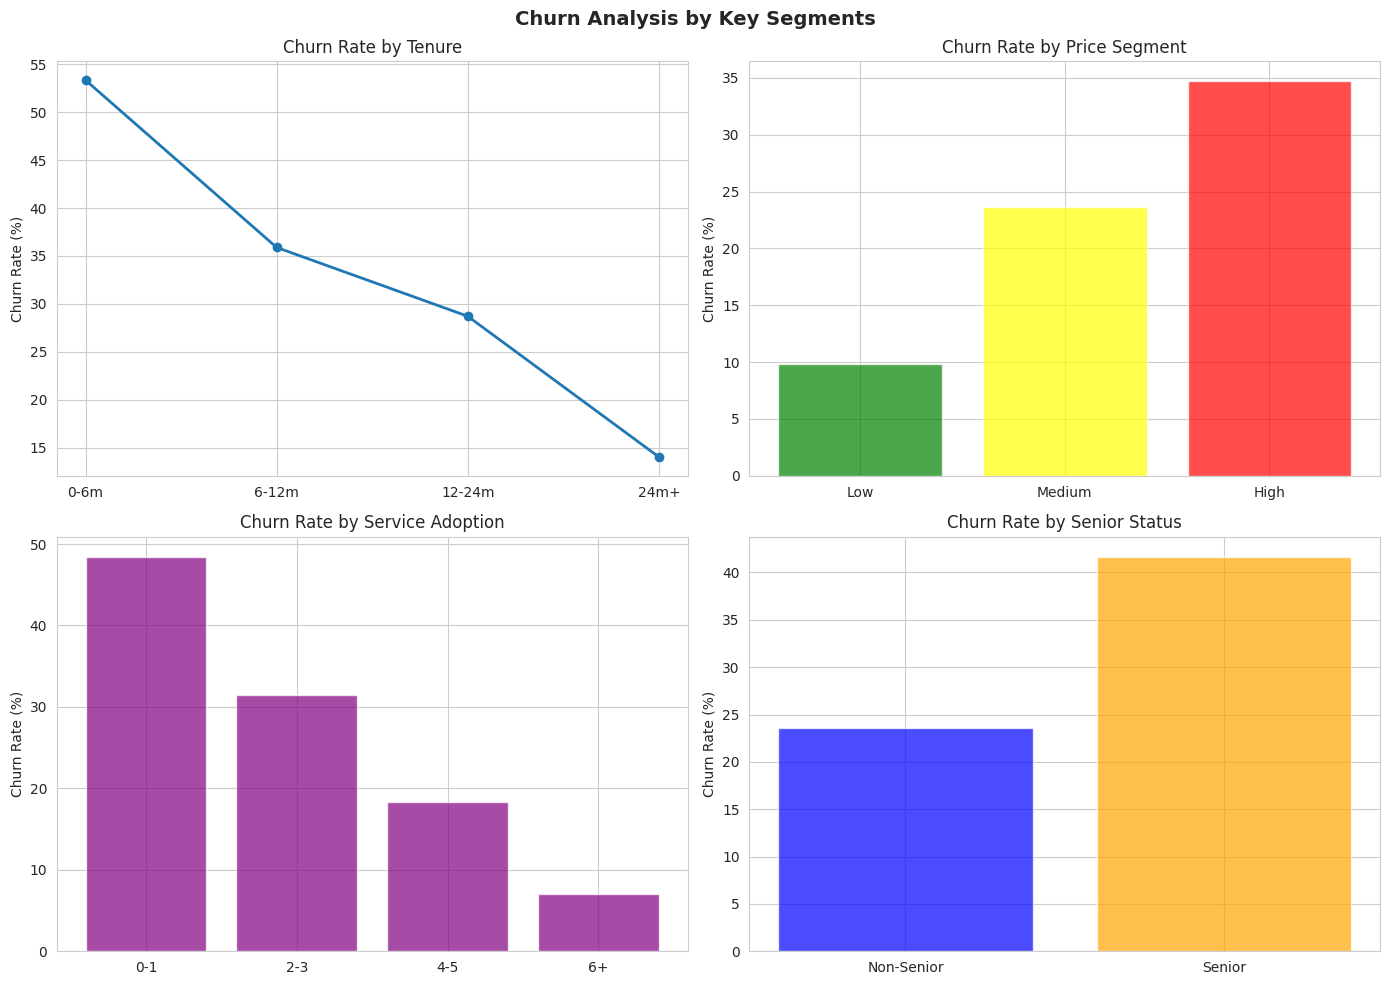

✓ Segmentation Analysis Complete


In [54]:
# Type 3: Segmentation & Advanced Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analysis by Key Segments', fontsize=14, fontweight='bold')

# Churn by Tenure
tenure_bins = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 72])
churn_by_tenure = df.groupby(tenure_bins)['Churn'].mean() * 100
axes[0, 0].plot(range(len(churn_by_tenure)), churn_by_tenure.values, marker='o', linewidth=2)
axes[0, 0].set_xticks(range(len(churn_by_tenure)))
axes[0, 0].set_xticklabels(['0-6m', '6-12m', '12-24m', '24m+'])
axes[0, 0].set_title('Churn Rate by Tenure')
axes[0, 0].set_ylabel('Churn Rate (%)')

# Churn by Monthly Charges
charge_bins = pd.cut(df['MonthlyCharges'], bins=[0, 30, 65, 150])
churn_by_charges = df.groupby(charge_bins)['Churn'].mean() * 100
axes[0, 1].bar(range(len(churn_by_charges)), churn_by_charges.values, color=['green', 'yellow', 'red'], alpha=0.7)
axes[0, 1].set_xticks(range(len(churn_by_charges)))
axes[0, 1].set_xticklabels(['Low', 'Medium', 'High'])
axes[0, 1].set_title('Churn Rate by Price Segment')
axes[0, 1].set_ylabel('Churn Rate (%)')

# Churn by Service Count
service_bins = pd.cut(df['ServiceCount'], bins=[-1, 1, 3, 5, 8])
churn_by_service = df.groupby(service_bins)['Churn'].mean() * 100
axes[1, 0].bar(range(len(churn_by_service)), churn_by_service.values, color='purple', alpha=0.7)
axes[1, 0].set_xticks(range(len(churn_by_service)))
axes[1, 0].set_xticklabels(['0-1', '2-3', '4-5', '6+'])
axes[1, 0].set_title('Churn Rate by Service Adoption')
axes[1, 0].set_ylabel('Churn Rate (%)')

# Churn by Senior Status
churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean() * 100
axes[1, 1].bar(['Non-Senior', 'Senior'], churn_by_senior.values, color=['blue', 'orange'], alpha=0.7)
axes[1, 1].set_title('Churn Rate by Senior Status')
axes[1, 1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()
print('✓ Segmentation Analysis Complete')


---

[← Data Quality & Preprocessing Study](02_preprocessing_study.ipynb) · [Next: Modelling, Evaluation & Business Insights →](04_modelling_evaluation_insights.ipynb)